In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *
import pandas as pd
from joblib import Parallel, delayed

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

gz_df = pd.read_csv('/Users/hyp0515/data/gz_desi_deep_learning_catalog_friendly.csv')

In [3]:
# dp_samples_ids      = read_ids('dp_samples_ids.txt')
# nbcs_samples_ids    = read_ids('nbcs_samples_ids.txt')
# cs_samples_ids      = read_ids('cs_samples_ids.txt')
# cs_wo_nb_samples_ids = [tid for tid in cs_samples_ids if tid not in nbcs_samples_ids]

# DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_samples_ids)
# NBCS_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=nbcs_samples_ids)
# CS_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=cs_samples_ids)
# CS_WO_NB_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=cs_wo_nb_samples_ids)

dp_samples_regime1  = read_ids('dp_samples_regime1_ids.txt')
dp_samples_regime2  = read_ids('dp_samples_regime2_ids.txt')
dp_samples_regime3  = read_ids('dp_samples_regime3_ids.txt')
dp_samples_regime4  = read_ids('dp_samples_regime4_ids.txt')

DP1_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_samples_regime1)
DP2_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_samples_regime2)
DP3_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_samples_regime3)
DP4_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_samples_regime4)

In [4]:
from scipy.spatial import KDTree

# Create a KDTree for fast spatial queries on the Galaxy Zoo dataframe
# Note: We only need to do this once.
gz_coords = np.c_[gz_df['ra'], gz_df['dec']]
gz_tree = KDTree(gz_coords)

def find_all_matches(spectra_df, gz_df, gz_tree, search_radius_deg=0.001):
    """
    Finds the closest match in gz_df for each object in spectra_df using a KDTree.
    """
    # Get coordinates from the spectra dataframe
    spectra_coords = np.c_[spectra_df['RA'], spectra_df['DEC']]
    
    # Query the tree to find the nearest neighbor for each spectrum object
    # It returns the distance and the index of the neighbor in gz_df
    distances, indices = gz_tree.query(spectra_coords, k=1)
    
    # Convert search radius from degrees to the squared distance used by the tree
    # This is a good approximation for small angular separations.
    max_distance = search_radius_deg
    
    # Filter out matches that are outside the search radius
    valid_indices_mask = distances < max_distance
    
    # Get the indices from gz_df for valid matches
    matched_gz_indices = indices[valid_indices_mask]
    
    # Create a new dataframe with the matched morphological data
    matched_df = gz_df.iloc[matched_gz_indices].copy()
    
    # Get the corresponding data from the spectra dataframe to merge
    matched_spectra_df = spectra_df[valid_indices_mask].copy()
    
    # Reset indices to allow for a clean merge
    matched_df.reset_index(drop=True, inplace=True)
    matched_spectra_df.reset_index(drop=True, inplace=True)
    
    # Combine the dataframes side-by-side
    # This merges the original spectra info with the new morphology info
    result_df = pd.concat([matched_spectra_df, matched_df], axis=1)
    result_df.drop(columns=['catalog_version', 'legacy_survey_data_release', 'brickid', 'objid', 'brickid'], errors='ignore', inplace=True)
    result_df.drop(columns=['SPECTYPE', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'z_pipe'], errors='ignore', inplace=True)
    return result_df

# Find matches for both DP and NBCS samples
# dp_morph_df = find_all_matches(DP_SPECTRA.df, gz_df, gz_tree)
# nbcs_morph_df = find_all_matches(NBCS_SPECTRA.df, gz_df, gz_tree)
# cs_morph_df = find_all_matches(CS_SPECTRA.df, gz_df, gz_tree)
# cs_wo_nb_morph_df = find_all_matches(CS_WO_NB_SPECTRA.df, gz_df, gz_tree)

# print("DP matches found:", len(dp_morph_df))
# print("NBCS matches found:", len(nbcs_morph_df))
# print("CS matches found:", len(cs_morph_df))
# print("CS without NBCS matches found:", len(cs_wo_nb_morph_df))
# dp_morph_df.head()



DP1_morph_df = find_all_matches(DP1_SPECTRA.df, gz_df, gz_tree)
DP2_morph_df = find_all_matches(DP2_SPECTRA.df, gz_df, gz_tree)
DP3_morph_df = find_all_matches(DP3_SPECTRA.df, gz_df, gz_tree)
DP4_morph_df = find_all_matches(DP4_SPECTRA.df, gz_df, gz_tree)

print("DP Regime 1 matches found:", len(DP1_morph_df))
print("DP Regime 2 matches found:", len(DP2_morph_df))
print("DP Regime 3 matches found:", len(DP3_morph_df))
print("DP Regime 4 matches found:", len(DP4_morph_df))



DP Regime 1 matches found: 4432
DP Regime 2 matches found: 2269
DP Regime 3 matches found: 2699
DP Regime 4 matches found: 2525


In [5]:
# print(dp_morph_df.columns)

In [6]:
smoothness_cols = ['smooth-or-featured_smooth_fraction', 'smooth-or-featured_featured-or-disk_fraction', 'smooth-or-featured_artifact_fraction']
smoothness_class = ['Smooth', 'Featured', 'Artifact']

roundness_cols = ['how-rounded_round_fraction', 'how-rounded_in-between_fraction', 'how-rounded_cigar-shaped_fraction']
roundness_class = ['Round', 'In-between', 'Cigar-shaped']


edge_on_cols = ['disk-edge-on_yes_fraction', 'disk-edge-on_no_fraction']
edge_on_class = ['Edge-on', 'Face-on']

bar_cols = ['bar_strong_fraction', 'bar_weak_fraction', 'bar_no_fraction']
bar_class = ['Strong Bar', 'Weak Bar', 'No Bar']

spiral_cols = ['has-spiral-arms_yes_fraction', 'has-spiral-arms_no_fraction']
spiral_class = ['Spiral', 'Non-spiral']

spiral_winding_cols = ['spiral-winding_tight_fraction', 'spiral-winding_medium_fraction', 'spiral-winding_loose_fraction']
spiral_winding_class = ['Tight Spiral', 'Medium Spiral', 'Loose Spiral']

merger_cols = ['merging_none_fraction', 'merging_minor-disturbance_fraction', 'merging_major-disturbance_fraction', 'merging_merger_fraction']
merger_class = ['No Merging', 'Minor Disturbance', 'Major Disturbance', 'Merger']

bulge_cols = ['bulge-size_dominant_fraction', 'bulge-size_large_fraction', 'bulge-size_moderate_fraction', 'bulge-size_small_fraction', 'bulge-size_none_fraction']
bulge_class = ['Dominant Bulge', 'Large Bulge', 'Moderate Bulge', 'Small Bulge', 'No Bulge']

classes = {
    'smoothness': (smoothness_cols, smoothness_class),
    'roundness': (roundness_cols, roundness_class),
    'edge_on': (edge_on_cols, edge_on_class),
    'bar': (bar_cols, bar_class),
    'spiral': (spiral_cols, spiral_class),
    'spiral_winding': (spiral_winding_cols, spiral_winding_class),
    'merger': (merger_cols, merger_class),
    'bulge': (bulge_cols, bulge_class)
}


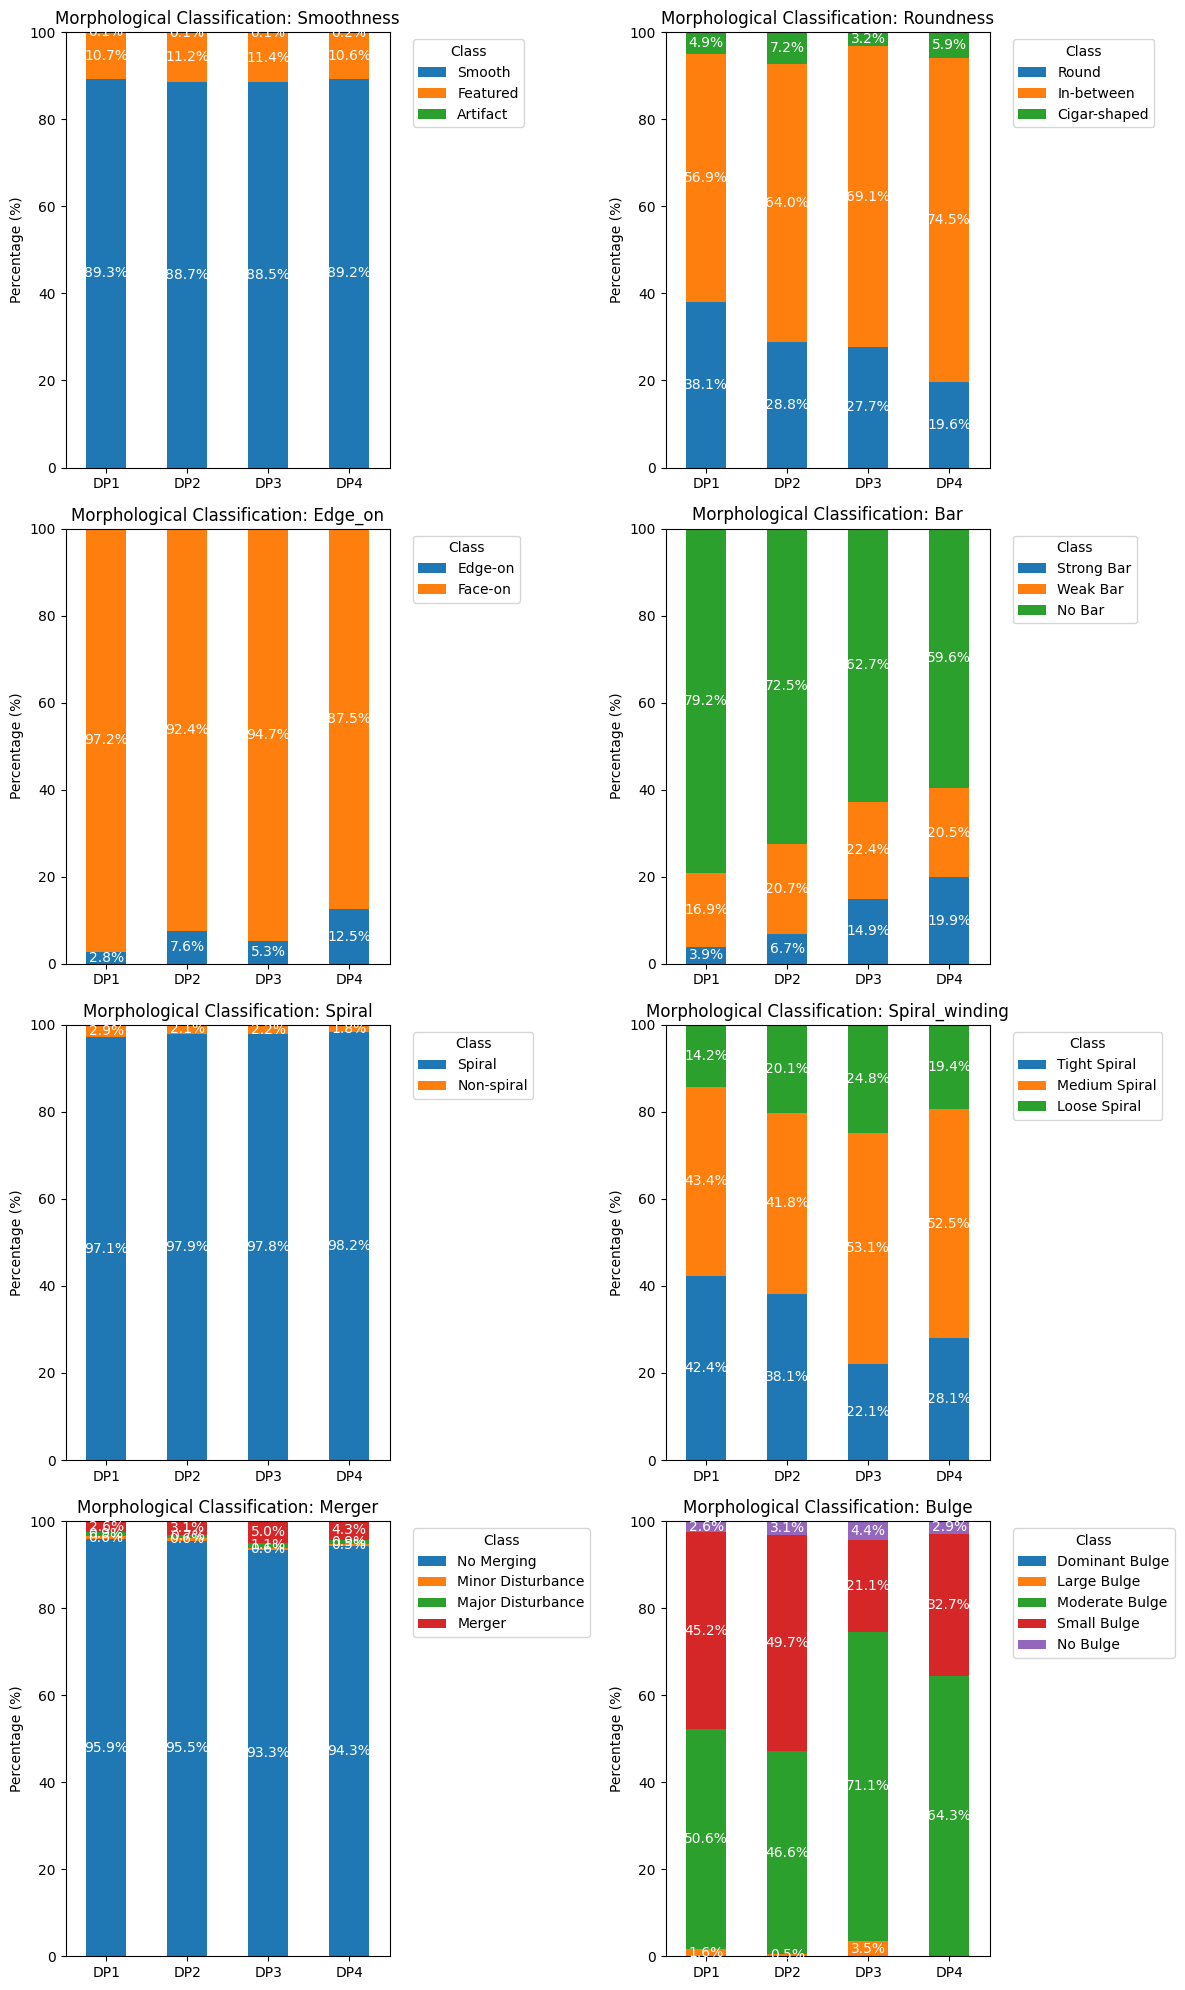

In [7]:
def get_classification_percentages(df, cols, class_names):
    """
    Calculates the percentage of each classification for a given set of columns in a dataframe.
    """
    # Select the relevant columns and drop rows where all values are NaN
    sub_df = df[cols].dropna(how='all')
    total = len(sub_df)
    
    if total == 0:
        # Return a series of zeros if there are no classified samples
        return pd.Series([0] * len(class_names), index=class_names)

    # Find the column with the highest fraction for each row
    highest_fraction_col = sub_df.idxmax(axis=1)
    
    # Count the occurrences of each classification
    classification_counts = highest_fraction_col.value_counts()
    
    # Map column names to class names and calculate percentages
    percentages = {}
    for i, col_name in enumerate(cols):
        class_name = class_names[i]
        count = classification_counts.get(col_name, 0)
        percentages[class_name] = (count / total) * 100
        
    return pd.Series(percentages)

# Prepare data for plotting
plot_data = {}
for name, (cols, class_names) in classes.items():
    # dp_percentages = get_classification_percentages(dp_morph_df, cols, class_names)
    # nbcs_percentages = get_classification_percentages(nbcs_morph_df, cols, class_names)
    # cs_percentages = get_classification_percentages(cs_morph_df, cols, class_names)
    # cs_wo_nb_percentages = get_classification_percentages(cs_wo_nb_morph_df, cols, class_names)
    
    dp1_percentages = get_classification_percentages(DP1_morph_df, cols, class_names)
    dp2_percentages = get_classification_percentages(DP2_morph_df, cols, class_names)
    dp3_percentages = get_classification_percentages(DP3_morph_df, cols, class_names)
    dp4_percentages = get_classification_percentages(DP4_morph_df, cols, class_names)

    # Combine the results into a single DataFrame
    # combined_df = pd.DataFrame({'DP': dp_percentages, 'NBCS': nbcs_percentages, 'CS': cs_percentages, 'CS-NBCS': cs_wo_nb_percentages})
    combined_df = pd.DataFrame({'DP1': dp1_percentages, 'DP2': dp2_percentages, 'DP3': dp3_percentages, 'DP4': dp4_percentages})
    plot_data[name] = combined_df

# Create subplots for each classification category
# Determine grid size for subplots
n_items = len(plot_data)
n_cols = 2
n_rows = (n_items + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, (name, df) in enumerate(plot_data.items()):
    # Transpose the DataFrame to have samples (DP, CS) on the x-axis
    df.T.plot(kind='bar', stacked=True, ax=axes[i], rot=0)
    axes[i].set_title(f'Morphological Classification: {name.capitalize()}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[i].set_ylim(0, 100)

    # Add percentage labels to each container
    for container in axes[i].containers:
        # Create labels, but only for bars with height > 0
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
        axes[i].bar_label(container, labels=labels, label_type='center', color='white')


# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('./figures/Jan7/morphological_classification_dp_regime.png')
plt.show()